# PDF Document Splitter using Qwen VL

This notebook uses Qwen's Vision Language Model to analyze a multi-document PDF and split it into separate files.

**Workflow:**
1. Convert PDF pages to images
2. Use Qwen VL API to analyze each page:
   - Identify "starting pages" (first page of a new document)
   - Detect if the page needs rotation correction
3. Store the indices of starting pages and rotation requirements
4. Split the PDF into multiple files, applying rotation corrections as needed

## 1. Setup and Configuration

In [1]:
import os
import io
import base64
import json
from pathlib import Path
from typing import List, Tuple, Literal
from dataclasses import dataclass

from pdf2image import convert_from_path
from pypdf import PdfReader, PdfWriter
from PIL import Image
from dotenv import load_dotenv
from tqdm import tqdm
import pytesseract  # For reliable rotation detection

# DSPy for optimizable LLM calls
import dspy
from pydantic import BaseModel, Field

# Load environment variables
load_dotenv()

print("Libraries loaded successfully!")
print(f"Tesseract version: {pytesseract.get_tesseract_version()}")

/Users/xavierau/Code/python/ai_document_processing/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Libraries loaded successfully!
Tesseract version: 5.5.1


In [2]:
# Configuration
@dataclass
class Config:
    # Qwen API settings
    api_key: str = os.getenv("DASHSCOPE_API_KEY", "")
    base_url: str = "https://dashscope-intl.aliyuncs.com/compatible-mode/v1"
    model: str = "qwen3-vl-32b-instruct"  # or "qwen3-vl-8b-instruct" for faster/cheaper
    
    # Image processing settings
    dpi: int = 150  # Lower DPI for faster processing, increase for better accuracy
    max_image_size: int = 1024  # Max dimension for images sent to API
    
    # Output settings
    output_dir: str = "./split_output"

config = Config()

# Validate API key
if not config.api_key:
    raise ValueError("DASHSCOPE_API_KEY not found in environment variables!")

print(f"Using model: {config.model}")
print(f"Output directory: {config.output_dir}")

Using model: qwen3-vl-32b-instruct
Output directory: ./split_output


In [3]:
# Initialize DSPy with Qwen via Dashscope (OpenAI-compatible)
lm = dspy.LM(
    model=f"openai/{config.model}",
    api_key=config.api_key,
    api_base=config.base_url,
    temperature=0.1,
)
dspy.configure(lm=lm)

print(f"DSPy configured with: {config.model}")

DSPy configured with: qwen3-vl-32b-instruct


## 2. Helper Functions

In [4]:
def pdf_to_images(pdf_path: str, dpi: int = 150) -> List[Image.Image]:
    """
    Convert PDF pages to PIL images.
    
    Args:
        pdf_path: Path to the PDF file
        dpi: Resolution for conversion
        
    Returns:
        List of PIL Image objects, one per page
    """
    print(f"Converting PDF to images at {dpi} DPI...")
    images = convert_from_path(pdf_path, dpi=dpi)
    print(f"Converted {len(images)} pages")
    return images

In [5]:
def resize_image(image: Image.Image, max_size: int = 1024) -> Image.Image:
    """
    Resize image to fit within max_size while maintaining aspect ratio.
    
    Args:
        image: PIL Image
        max_size: Maximum dimension (width or height)
        
    Returns:
        Resized PIL Image
    """
    width, height = image.size
    
    if width <= max_size and height <= max_size:
        return image
    
    if width > height:
        new_width = max_size
        new_height = int(height * (max_size / width))
    else:
        new_height = max_size
        new_width = int(width * (max_size / height))
    
    return image.resize((new_width, new_height), Image.Resampling.LANCZOS)

In [6]:
def image_to_base64(image: Image.Image) -> str:
    """
    Convert PIL Image to base64 string.
    
    Args:
        image: PIL Image
        
    Returns:
        Base64 encoded string
    """
    buffer = io.BytesIO()
    image.save(buffer, format="PNG")
    buffer.seek(0)
    return base64.b64encode(buffer.read()).decode("utf-8")


def rotate_image(image: Image.Image, rotation_degrees: int) -> Image.Image:
    """
    Rotate a PIL Image by the specified degrees.
    
    Args:
        image: PIL Image to rotate
        rotation_degrees: Degrees to rotate (0, 90, 180, 270)
                         Positive = counter-clockwise
        
    Returns:
        Rotated PIL Image
    """
    if rotation_degrees == 0:
        return image
    
    # Normalize to 0, 90, 180, 270
    rotation_degrees = rotation_degrees % 360
    
    if rotation_degrees == 90:
        return image.transpose(Image.Transpose.ROTATE_90)
    elif rotation_degrees == 180:
        return image.transpose(Image.Transpose.ROTATE_180)
    elif rotation_degrees == 270:
        return image.transpose(Image.Transpose.ROTATE_270)
    else:
        # For arbitrary angles, use rotate (with expand to avoid cropping)
        return image.rotate(rotation_degrees, expand=True, fillcolor='white')


def detect_rotation_tesseract(image: Image.Image) -> dict:
    """
    Detect page rotation using Tesseract OCR's Orientation and Script Detection (OSD).
    
    This is MORE RELIABLE than VLLMs for rotation detection because Tesseract
    specifically analyzes text line angles rather than trying to "read" the content.
    
    Args:
        image: PIL Image
        
    Returns:
        Dictionary with:
        - rotation_needed: int (0, 90, 180, 270)
        - confidence: float (0-100)
        - script: str (detected script, e.g., "Latin")
    """
    import pytesseract
    
    try:
        # Use OSD (Orientation and Script Detection) mode
        osd = pytesseract.image_to_osd(image, output_type=pytesseract.Output.DICT)
        
        # Tesseract returns the rotation angle of the text
        # We need to return the counter-clockwise rotation needed to fix it
        detected_angle = osd.get("rotate", 0)
        
        # Tesseract's rotate value is the angle the image is rotated
        # To correct it, we rotate by that amount counter-clockwise
        # But Tesseract already gives us the correction angle
        rotation_needed = detected_angle
        
        return {
            "rotation_needed": rotation_needed,
            "confidence": osd.get("orientation_conf", 0),
            "script": osd.get("script", "unknown"),
            "method": "tesseract_osd"
        }
        
    except Exception as e:
        # If OSD fails (e.g., not enough text), return 0
        return {
            "rotation_needed": 0,
            "confidence": 0,
            "script": "unknown",
            "method": "tesseract_osd",
            "error": str(e)
        }


def detect_rotation_hybrid(image: Image.Image, page_number: int) -> dict:
    """
    Hybrid rotation detection: Try Tesseract OSD first (more reliable),
    fall back to noting low confidence if it fails.
    
    Args:
        image: PIL Image
        page_number: Page number for logging
        
    Returns:
        Rotation detection result
    """
    result = detect_rotation_tesseract(image)
    
    if "error" in result or result["confidence"] < 1.0:
        # Low confidence or error - flag for manual review
        result["needs_review"] = True
    else:
        result["needs_review"] = False
    
    return result

In [7]:
from pydantic import BaseModel, Field


# ==============================================================================
# DSPy Signatures and Modules for Document Analysis
# ==============================================================================
# Using DSPy allows for future prompt optimization using techniques like:
# - BootstrapFewShot: Learn from examples
# - MIPRO: Multi-stage prompt optimization  
# - BootstrapFinetune: Fine-tune the model
# ==============================================================================

class DocumentAnalysisOutput(BaseModel):
    """Structured output for document page analysis."""
    is_starting_page: bool = Field(
        description="True if this is the first page of a new document, False if it's a continuation"
    )
    confidence: Literal["high", "medium", "low"] = Field(
        description="Confidence level of the assessment"
    )
    reason: str = Field(
        description="Brief explanation of why this is or is not a starting page"
    )
    document_type: str = Field(
        description="Type of document (e.g., invoice, receipt, form, letter, report, unknown)"
    )


class DocumentBoundaryDetection(dspy.Signature):
    """Analyze a document page image to determine if it's the first page of a new document.
    
    A starting page typically has:
    - Document header/title at the top
    - Company logo or letterhead  
    - Document number, date, or reference at the top
    - "Page 1" or similar indicator
    - Invoice header, receipt header, or form title
    - Fresh document layout (not a continuation)
    
    A NON-starting page (continuation) typically has:
    - Page numbers > 1
    - "Continued from..." text
    - No document header/title
    - Content that appears to continue from a previous page
    """
    
    image: dspy.Image = dspy.InputField(desc="The document page image to analyze")
    analysis: DocumentAnalysisOutput = dspy.OutputField(desc="Analysis result with is_starting_page, confidence, reason, and document_type")


class DocumentAnalyzer(dspy.Module):
    """DSPy Module for analyzing document pages.
    
    This module can be optimized using DSPy optimizers like:
    - dspy.BootstrapFewShot(metric=your_metric)
    - dspy.MIPROv2(metric=your_metric)
    """
    
    def __init__(self):
        super().__init__()
        self.predictor = dspy.ChainOfThought(DocumentBoundaryDetection)
    
    def forward(self, image: dspy.Image) -> DocumentAnalysisOutput:
        """Analyze a document page image.
        
        Args:
            image: DSPy Image object
            
        Returns:
            DocumentAnalysisOutput with analysis results
        """
        result = self.predictor(image=image)
        return result.analysis


# Initialize the analyzer module
document_analyzer = DocumentAnalyzer()

print("DSPy DocumentAnalyzer module initialized")
print("  • Signature: DocumentBoundaryDetection")
print("  • Output: DocumentAnalysisOutput (Pydantic model)")
print("  • Ready for optimization with BootstrapFewShot, MIPRO, etc.")

DSPy DocumentAnalyzer module initialized
  • Signature: DocumentBoundaryDetection
  • Output: DocumentAnalysisOutput (Pydantic model)
  • Ready for optimization with BootstrapFewShot, MIPRO, etc.


In [8]:
from dspy.adapters.image_utils import encode_image

def analyze_page_with_dspy(image: Image.Image, page_number: int, use_tesseract_for_rotation: bool = True) -> dict:
    """
    Analyze a page for document boundaries (using DSPy) and rotation (using Tesseract).
    
    Using DSPy allows for future optimization with:
    - BootstrapFewShot: Learn from labeled examples
    - MIPRO: Multi-stage prompt optimization
    - BootstrapFinetune: Fine-tune the underlying model
    
    Args:
        image: PIL Image of the page
        page_number: Page number (1-indexed) for logging
        use_tesseract_for_rotation: If True, use Tesseract OSD for rotation detection (recommended)
        
    Returns:
        Dictionary with analysis results
    """
    # ====================
    # ROTATION DETECTION (Tesseract - More Reliable)
    # ====================
    rotation_needed = 0
    rotation_confidence = "low"
    rotation_reason = "Not detected"
    
    if use_tesseract_for_rotation:
        rotation_result = detect_rotation_tesseract(image)
        rotation_needed = rotation_result["rotation_needed"]
        rotation_confidence = "high" if rotation_result["confidence"] > 5.0 else "medium" if rotation_result["confidence"] > 1.0 else "low"
        rotation_reason = f"Tesseract OSD detected {rotation_needed}° rotation (confidence: {rotation_result['confidence']:.1f})"
        if "error" in rotation_result:
            rotation_reason = f"Tesseract OSD error: {rotation_result['error']}, defaulting to 0°"
    
    # ====================
    # DOCUMENT BOUNDARY DETECTION (DSPy - Optimizable)
    # ====================
    # Resize image for API
    resized = resize_image(image, config.max_image_size)
    
    # Convert PIL Image to DSPy Image
    # Note: dspy.Image.from_PIL() has a bug - it calls PIL.Image.open() on an already-open image
    # So we use encode_image() directly which correctly handles PIL Images
    data_uri = encode_image(resized)
    dspy_image = dspy.Image(url=data_uri)
    
    try:
        # Use DSPy module for prediction
        result = document_analyzer(image=dspy_image)
        
        # Get token usage from DSPy's LM history
        token_usage = {"input_tokens": 0, "output_tokens": 0, "total_tokens": 0}
        if lm.history:
            last_call = lm.history[-1]
            if hasattr(last_call, 'usage') and last_call.usage:
                token_usage = {
                    "input_tokens": getattr(last_call.usage, 'prompt_tokens', 0) or 0,
                    "output_tokens": getattr(last_call.usage, 'completion_tokens', 0) or 0,
                    "total_tokens": getattr(last_call.usage, 'total_tokens', 0) or 0
                }
        
        # Convert Pydantic model to dict
        analysis_dict = {
            "is_starting_page": result.is_starting_page,
            "confidence": result.confidence,
            "reason": result.reason,
            "document_type": result.document_type,
            "rotation_needed": rotation_needed,
            "rotation_confidence": rotation_confidence,
            "rotation_reason": rotation_reason,
            "rotation_method": "tesseract_osd" if use_tesseract_for_rotation else "none",
            "token_usage": token_usage,
            "analysis_method": "dspy"
        }
        
        return analysis_dict
        
    except Exception as e:
        print(f"  Error analyzing page {page_number}: {e}")
        return {
            "is_starting_page": True,
            "confidence": "low",
            "reason": f"DSPy error: {str(e)}",
            "document_type": "unknown",
            "rotation_needed": rotation_needed,
            "rotation_confidence": rotation_confidence,
            "rotation_reason": rotation_reason,
            "rotation_method": "tesseract_osd" if use_tesseract_for_rotation else "none",
            "token_usage": {"input_tokens": 0, "output_tokens": 0, "total_tokens": 0},
            "analysis_method": "dspy_error"
        }


# Alias for backward compatibility
analyze_page_with_qwen = analyze_page_with_dspy

In [9]:
def find_document_boundaries(images: List[Image.Image]) -> List[dict]:
    """
    Analyze all pages to find document boundaries (DSPy) and rotation needs (Tesseract).
    
    Args:
        images: List of PIL Images (one per page)
        
    Returns:
        List of dictionaries with page analysis results
    """
    results = []
    total_input_tokens = 0
    total_output_tokens = 0
    
    print(f"\nAnalyzing {len(images)} pages...")
    print("  • Document boundaries: DSPy + Qwen VL (optimizable)")
    print("  • Rotation detection: Tesseract OSD (reliable)")
    print("="*90)
    print(f"{'Page':<6} {'Status':<8} {'Conf':<8} {'Type':<12} {'Rotation':<12} {'Method':<12} {'Tokens':<12}")
    print("-"*90)
    
    for i, image in enumerate(tqdm(images, desc="Analyzing pages")):
        page_num = i + 1  # 1-indexed
        
        analysis = analyze_page_with_dspy(image, page_num, use_tesseract_for_rotation=True)
        analysis["page_number"] = page_num
        analysis["page_index"] = i  # 0-indexed
        
        results.append(analysis)
        
        # Extract token usage
        token_usage = analysis.get("token_usage", {})
        input_tokens = token_usage.get("input_tokens", 0)
        output_tokens = token_usage.get("output_tokens", 0)
        total_input_tokens += input_tokens
        total_output_tokens += output_tokens
        
        # Print progress
        status = "START" if analysis["is_starting_page"] else "CONT."
        conf = analysis["confidence"]
        doc_type = analysis.get("document_type", "unknown")[:10]
        rotation = analysis.get("rotation_needed", 0)
        rot_indicator = f"↻{rotation}°" if rotation != 0 else "OK"
        method = analysis.get("rotation_method", "none")[:10]
        token_str = f"{input_tokens:,}/{output_tokens:,}"
        
        print(f"{page_num:<6} [{status}]  {conf:<8} {doc_type:<12} {rot_indicator:<12} {method:<12} {token_str:<12}")
    
    print("-"*90)
    print(f"{'TOTAL':<6} {'':<8} {'':<8} {'':<12} {'':<12} {'':<12} {total_input_tokens:,}/{total_output_tokens:,}")
    print(f"\nTotal tokens used: {total_input_tokens + total_output_tokens:,} (input: {total_input_tokens:,}, output: {total_output_tokens:,})")
    
    # Summary of rotations needed
    pages_needing_rotation = [r for r in results if r.get("rotation_needed", 0) != 0]
    if pages_needing_rotation:
        print(f"\n⚠️  {len(pages_needing_rotation)} page(s) need rotation:")
        for r in pages_needing_rotation:
            print(f"   Page {r['page_number']}: {r['rotation_needed']}° (detected by {r.get('rotation_method', 'unknown')})")
    else:
        print(f"\n✓ All pages are correctly oriented")
    
    return results

In [10]:
def get_starting_page_indices(analysis_results: List[dict]) -> List[int]:
    """
    Extract the 0-indexed page indices of starting pages.
    
    Args:
        analysis_results: List of page analysis dictionaries
        
    Returns:
        List of 0-indexed page indices that are starting pages
    """
    starting_indices = [
        result["page_index"]
        for result in analysis_results
        if result["is_starting_page"]
    ]
    
    # Always ensure page 0 is included as a starting page
    if 0 not in starting_indices:
        starting_indices.insert(0, 0)
    
    return sorted(starting_indices)

In [11]:
def split_pdf(
    pdf_path: str,
    starting_indices: List[int],
    output_dir: str,
    base_name: str = None,
    analysis_results: List[dict] = None,
    apply_rotation: bool = True
) -> List[str]:
    """
    Split a PDF into multiple files based on starting page indices,
    optionally applying rotation corrections.
    
    Args:
        pdf_path: Path to the source PDF
        starting_indices: List of 0-indexed starting page indices
        output_dir: Directory to save split PDFs
        base_name: Base name for output files (default: source filename)
        analysis_results: List of analysis results with rotation info
        apply_rotation: Whether to apply rotation corrections (default: True)
        
    Returns:
        List of paths to created PDF files
    """
    # Create output directory
    output_path = Path(output_dir)
    output_path.mkdir(parents=True, exist_ok=True)
    
    # Get base name from source file if not provided
    if base_name is None:
        base_name = Path(pdf_path).stem
    
    # Build rotation map from analysis results
    rotation_map = {}
    if analysis_results:
        for result in analysis_results:
            page_idx = result.get("page_index", result.get("page_number", 1) - 1)
            rotation_map[page_idx] = result.get("rotation_needed", 0)
    
    # Read source PDF
    reader = PdfReader(pdf_path)
    total_pages = len(reader.pages)
    
    print(f"\nSplitting PDF with {total_pages} pages into {len(starting_indices)} documents...")
    if apply_rotation and any(r != 0 for r in rotation_map.values()):
        print("Applying rotation corrections...")
    print("="*60)
    
    output_files = []
    
    for i, start_idx in enumerate(starting_indices):
        # Determine end index
        if i + 1 < len(starting_indices):
            end_idx = starting_indices[i + 1]
        else:
            end_idx = total_pages
        
        # Create new PDF with pages from start_idx to end_idx
        writer = PdfWriter()
        rotations_applied = []
        
        for page_idx in range(start_idx, end_idx):
            page = reader.pages[page_idx]
            
            # Apply rotation if needed
            rotation = rotation_map.get(page_idx, 0)
            if apply_rotation and rotation != 0:
                # Tesseract's 'rotate' value is the CLOCKWISE rotation needed to fix the image
                # pypdf's page.rotate() also uses CLOCKWISE rotation
                # So we use the value directly - no conversion needed!
                page.rotate(rotation)
                rotations_applied.append((page_idx + 1, rotation))
            
            writer.add_page(page)
        
        # Generate output filename
        doc_num = i + 1
        output_filename = f"{base_name}_doc{doc_num:03d}.pdf"
        output_filepath = output_path / output_filename
        
        # Write PDF
        with open(output_filepath, "wb") as f:
            writer.write(f)
        
        page_count = end_idx - start_idx
        rotation_info = ""
        if rotations_applied:
            rot_str = ", ".join([f"p{p}:{r}°CW" for p, r in rotations_applied])
            rotation_info = f" [Rotated: {rot_str}]"
        
        print(f"Document {doc_num}: pages {start_idx + 1}-{end_idx} ({page_count} pages) -> {output_filename}{rotation_info}")
        
        output_files.append(str(output_filepath))
    
    print(f"\nCreated {len(output_files)} PDF files in {output_dir}")
    return output_files

## 3. Main Processing Pipeline

In [12]:
def process_pdf(pdf_path: str, output_dir: str = None, apply_rotation: bool = True) -> Tuple[List[dict], List[str]]:
    """
    Complete pipeline to analyze and split a multi-document PDF.
    
    Args:
        pdf_path: Path to the PDF file
        output_dir: Directory for output files (default: config.output_dir)
        apply_rotation: Whether to apply rotation corrections (default: True)
        
    Returns:
        Tuple of (analysis_results, output_file_paths)
    """
    if output_dir is None:
        output_dir = config.output_dir
    
    print(f"Processing: {pdf_path}")
    print("="*60)
    
    # Step 1: Convert PDF to images
    images = pdf_to_images(pdf_path, dpi=config.dpi)
    
    # Step 2: Analyze each page for document boundaries and rotation
    analysis_results = find_document_boundaries(images)
    
    # Step 3: Get starting page indices
    starting_indices = get_starting_page_indices(analysis_results)
    print(f"\nFound {len(starting_indices)} documents starting at pages: {[i+1 for i in starting_indices]}")
    
    # Step 4: Split the PDF (with rotation if enabled)
    output_files = split_pdf(
        pdf_path, 
        starting_indices, 
        output_dir,
        analysis_results=analysis_results,
        apply_rotation=apply_rotation
    )
    
    return analysis_results, output_files

## 4. Run the Splitter

**Instructions:**
1. Set the `PDF_PATH` variable to point to your multi-document PDF
2. Optionally adjust `OUTPUT_DIR` for where to save split files
3. Run the cells below

In [13]:
# ============================================
# CONFIGURE YOUR PDF PATH HERE
# ============================================

PDF_PATH = "../invoice_set_1.pdf"  # <-- Change this to your PDF path
OUTPUT_DIR = "./split_output"  # <-- Change this if needed

# Verify file exists
if not os.path.exists(PDF_PATH):
    print(f"ERROR: PDF file not found: {PDF_PATH}")
    print("Please update PDF_PATH to point to your PDF file.")
else:
    print(f"PDF file found: {PDF_PATH}")
    print(f"Output will be saved to: {OUTPUT_DIR}")

PDF file found: ../invoice_set_1.pdf
Output will be saved to: ./split_output


In [14]:
# Run the processing pipeline
if os.path.exists(PDF_PATH):
    analysis_results, output_files = process_pdf(PDF_PATH, OUTPUT_DIR)
else:
    print("Please set a valid PDF_PATH first.")

Processing: ../invoice_set_1.pdf
Converting PDF to images at 150 DPI...
Converted 4 pages

Analyzing 4 pages...
  • Document boundaries: DSPy + Qwen VL (optimizable)
  • Rotation detection: Tesseract OSD (reliable)
Page   Status   Conf     Type         Rotation     Method       Tokens      
------------------------------------------------------------------------------------------


Analyzing pages:  25%|██▌       | 1/4 [00:00<00:02,  1.31it/s]

1      [START]  high     invoice      OK           tesseract_   0/0         


Analyzing pages:  50%|█████     | 2/4 [00:01<00:01,  1.31it/s]

2      [START]  high     receipt      ↻90°         tesseract_   0/0         


Analyzing pages:  75%|███████▌  | 3/4 [00:02<00:00,  1.36it/s]

3      [START]  high     invoice      OK           tesseract_   0/0         


Analyzing pages: 100%|██████████| 4/4 [00:02<00:00,  1.36it/s]

4      [START]  high     invoice      OK           tesseract_   0/0         
------------------------------------------------------------------------------------------
TOTAL                                                           0/0

Total tokens used: 0 (input: 0, output: 0)

⚠️  1 page(s) need rotation:
   Page 2: 90° (detected by tesseract_osd)

Found 4 documents starting at pages: [1, 2, 3, 4]

Splitting PDF with 4 pages into 4 documents...
Applying rotation corrections...
Document 1: pages 1-1 (1 pages) -> invoice_set_1_doc001.pdf
Document 2: pages 2-2 (1 pages) -> invoice_set_1_doc002.pdf [Rotated: p2:90°CW]
Document 3: pages 3-3 (1 pages) -> invoice_set_1_doc003.pdf
Document 4: pages 4-4 (1 pages) -> invoice_set_1_doc004.pdf

Created 4 PDF files in ./split_output


## 5. Review Results

In [15]:
# Display detailed analysis results
if 'analysis_results' in dir():
    print("\nDetailed Analysis Results:")
    print("="*80)
    
    total_tokens = {"input": 0, "output": 0}
    
    for result in analysis_results:
        page = result["page_number"]
        is_start = "YES" if result["is_starting_page"] else "NO"
        conf = result["confidence"]
        doc_type = result.get("document_type", "unknown")
        reason = result.get("reason", "N/A")
        rotation = result.get("rotation_needed", 0)
        rot_conf = result.get("rotation_confidence", "N/A")
        rot_reason = result.get("rotation_reason", "N/A")
        
        # Token usage
        token_usage = result.get("token_usage", {})
        input_tokens = token_usage.get("input_tokens", 0)
        output_tokens = token_usage.get("output_tokens", 0)
        total_tokens["input"] += input_tokens
        total_tokens["output"] += output_tokens
        
        print(f"\nPage {page}:")
        print(f"  Starting Page: {is_start}")
        print(f"  Confidence: {conf}")
        print(f"  Document Type: {doc_type}")
        print(f"  Reason: {reason}")
        print(f"  ---")
        print(f"  Rotation Needed: {rotation}°")
        print(f"  Rotation Confidence: {rot_conf}")
        print(f"  Rotation Reason: {rot_reason}")
        print(f"  ---")
        print(f"  Token Usage: {input_tokens:,} input + {output_tokens:,} output = {input_tokens + output_tokens:,} total")
    
    print("\n" + "="*80)
    print(f"TOTAL TOKEN USAGE: {total_tokens['input']:,} input + {total_tokens['output']:,} output = {total_tokens['input'] + total_tokens['output']:,} total")


Detailed Analysis Results:

Page 1:
  Starting Page: YES
  Confidence: high
  Document Type: invoice
  Reason: Document contains company header, invoice number, date, and title at the top, with no page numbers or continuation indicators, indicating it is the first page of a new invoice.
  ---
  Rotation Needed: 0°
  Rotation Confidence: high
  Rotation Reason: Tesseract OSD detected 0° rotation (confidence: 6.7)
  ---
  Token Usage: 0 input + 0 output = 0 total

Page 2:
  Starting Page: YES
  Confidence: high
  Document Type: receipt
  Reason: The document has a clear header with company name and logo, a date, and explicit page numbering 'PAGE 1 of 1', indicating it is the first and only page of the document.
  ---
  Rotation Needed: 90°
  Rotation Confidence: high
  Rotation Reason: Tesseract OSD detected 90° rotation (confidence: 10.1)
  ---
  Token Usage: 0 input + 0 output = 0 total

Page 3:
  Starting Page: YES
  Confidence: high
  Document Type: invoice
  Reason: The document di

In [16]:
# List output files
if 'output_files' in dir():
    print("\nGenerated Files:")
    print("="*60)
    
    for i, filepath in enumerate(output_files, 1):
        size = os.path.getsize(filepath) / 1024  # KB
        print(f"{i}. {filepath} ({size:.1f} KB)")


Generated Files:
1. split_output/invoice_set_1_doc001.pdf (70.3 KB)
2. split_output/invoice_set_1_doc002.pdf (71.8 KB)
3. split_output/invoice_set_1_doc003.pdf (107.9 KB)
4. split_output/invoice_set_1_doc004.pdf (93.8 KB)


In [17]:
# Save analysis results to JSON
if 'analysis_results' in dir():
    output_json_path = os.path.join(OUTPUT_DIR, "analysis_results.json")
    
    with open(output_json_path, "w") as f:
        json.dump(analysis_results, f, indent=2)
    
    print(f"Analysis results saved to: {output_json_path}")

Analysis results saved to: ./split_output/analysis_results.json


## 6. Visual Preview & Manual Rotation Correction

If the automatic rotation detection was incorrect, you can:
1. Preview page thumbnails to visually verify orientation
2. Manually specify rotation corrections
3. Re-split with the corrections applied

Generating page previews...


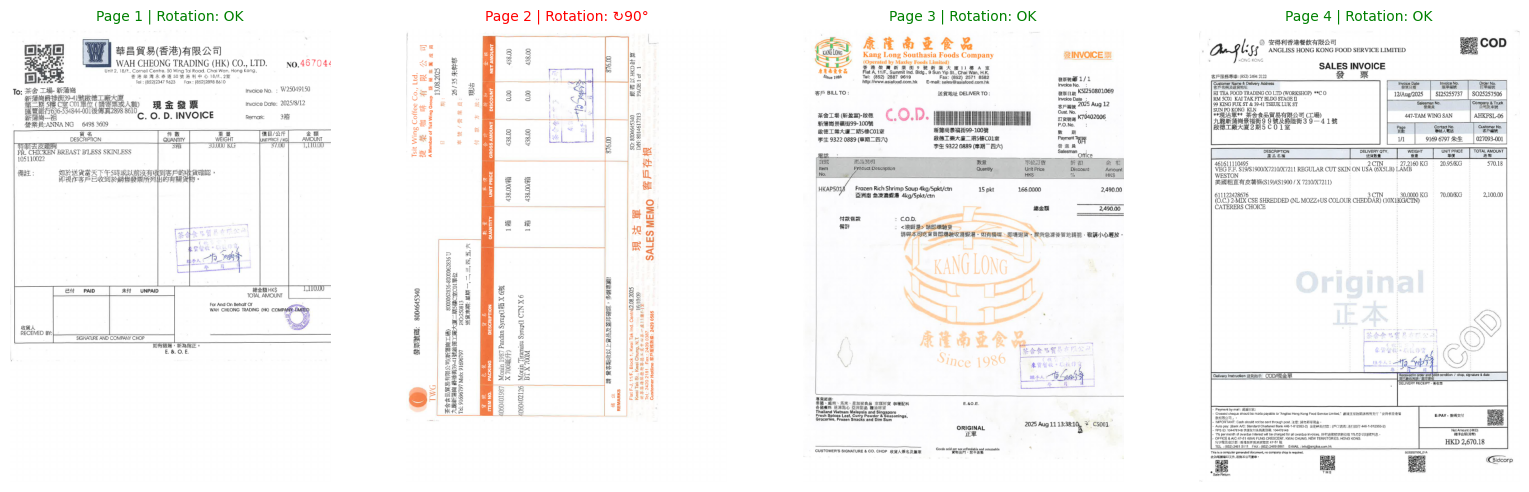


Rotation Summary:
----------------------------------------
  Page 1: No rotation needed
  Page 2: ↻90° correction
  Page 3: No rotation needed
  Page 4: No rotation needed


In [18]:
def preview_pages(pdf_path: str, analysis_results: List[dict] = None, max_width: int = 300):
    """
    Display thumbnail previews of all pages with their detected rotation.
    
    Args:
        pdf_path: Path to the PDF file
        analysis_results: Analysis results with rotation info
        max_width: Maximum width for thumbnails
    """
    import matplotlib.pyplot as plt
    
    # Convert PDF to images at low DPI for preview
    images = convert_from_path(pdf_path, dpi=72)
    
    # Build rotation map
    rotation_map = {}
    if analysis_results:
        for result in analysis_results:
            page_idx = result.get("page_index", result.get("page_number", 1) - 1)
            rotation_map[page_idx] = result.get("rotation_needed", 0)
    
    # Calculate grid layout
    n_pages = len(images)
    cols = min(4, n_pages)
    rows = (n_pages + cols - 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 5 * rows))
    if n_pages == 1:
        axes = [[axes]]
    elif rows == 1:
        axes = [axes]
    elif cols == 1:
        axes = [[ax] for ax in axes]
    
    for i, image in enumerate(images):
        row, col = i // cols, i % cols
        ax = axes[row][col]
        
        rotation = rotation_map.get(i, 0)
        
        # Show the image
        ax.imshow(image)
        ax.axis('off')
        
        # Title with rotation info
        rot_status = f"↻{rotation}°" if rotation != 0 else "OK"
        color = 'red' if rotation != 0 else 'green'
        ax.set_title(f"Page {i+1} | Rotation: {rot_status}", fontsize=10, color=color)
    
    # Hide empty subplots
    for i in range(n_pages, rows * cols):
        row, col = i // cols, i % cols
        axes[row][col].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    print("\nRotation Summary:")
    print("-" * 40)
    for i in range(n_pages):
        rotation = rotation_map.get(i, 0)
        status = f"↻{rotation}° correction" if rotation != 0 else "No rotation needed"
        print(f"  Page {i+1}: {status}")


# Preview pages (run after processing)
if 'analysis_results' in dir() and os.path.exists(PDF_PATH):
    print("Generating page previews...")
    preview_pages(PDF_PATH, analysis_results)
else:
    print("Run the processing pipeline first to generate previews.")

In [19]:
# ============================================
# MANUAL ROTATION CORRECTION
# ============================================
# If the LLM detected rotation incorrectly, specify manual corrections here.
# Format: {page_number: rotation_degrees}
# - page_number is 1-indexed (Page 1, Page 2, etc.)
# - rotation_degrees: 0, 90, 180, or 270 (counter-clockwise)
#
# Example: Page 2 needs 180° rotation, Page 5 needs 90° rotation
# MANUAL_ROTATION_CORRECTIONS = {2: 180, 5: 90}

MANUAL_ROTATION_CORRECTIONS = {
    2: 180,  # <-- Adjust this based on your visual inspection
}

def apply_manual_corrections(analysis_results: List[dict], corrections: dict) -> List[dict]:
    """
    Apply manual rotation corrections to analysis results.
    
    Args:
        analysis_results: Original analysis results
        corrections: Dict of {page_number: rotation_degrees}
        
    Returns:
        Updated analysis results with manual corrections applied
    """
    updated_results = []
    
    for result in analysis_results:
        updated = result.copy()
        page_num = result["page_number"]
        
        if page_num in corrections:
            old_rotation = result.get("rotation_needed", 0)
            new_rotation = corrections[page_num]
            updated["rotation_needed"] = new_rotation
            updated["rotation_confidence"] = "manual"
            updated["rotation_reason"] = f"Manually corrected from {old_rotation}° to {new_rotation}°"
            print(f"  Page {page_num}: {old_rotation}° -> {new_rotation}° (manual correction)")
        
        updated_results.append(updated)
    
    return updated_results


# Apply manual corrections and re-split
if 'analysis_results' in dir() and MANUAL_ROTATION_CORRECTIONS:
    print("Applying manual rotation corrections...")
    print("-" * 40)
    
    corrected_results = apply_manual_corrections(analysis_results, MANUAL_ROTATION_CORRECTIONS)
    
    # Re-split with corrections
    print("\nRe-splitting PDF with manual corrections...")
    corrected_output_dir = OUTPUT_DIR + "_corrected"
    
    starting_indices = get_starting_page_indices(corrected_results)
    corrected_output_files = split_pdf(
        PDF_PATH,
        starting_indices,
        corrected_output_dir,
        analysis_results=corrected_results,
        apply_rotation=True
    )
    
    print(f"\n✓ Corrected files saved to: {corrected_output_dir}")
else:
    print("No manual corrections specified. Set MANUAL_ROTATION_CORRECTIONS above if needed.")

Applying manual rotation corrections...
----------------------------------------
  Page 2: 90° -> 180° (manual correction)

Re-splitting PDF with manual corrections...

Splitting PDF with 4 pages into 4 documents...
Applying rotation corrections...
Document 1: pages 1-1 (1 pages) -> invoice_set_1_doc001.pdf
Document 2: pages 2-2 (1 pages) -> invoice_set_1_doc002.pdf [Rotated: p2:180°CW]
Document 3: pages 3-3 (1 pages) -> invoice_set_1_doc003.pdf
Document 4: pages 4-4 (1 pages) -> invoice_set_1_doc004.pdf

Created 4 PDF files in ./split_output_corrected

✓ Corrected files saved to: ./split_output_corrected


## 7. Batch Processing (Optional)

Process multiple PDFs in a directory.

In [20]:
def batch_process_pdfs(input_dir: str, output_base_dir: str) -> dict:
    """
    Process all PDFs in a directory.
    
    Args:
        input_dir: Directory containing PDF files
        output_base_dir: Base directory for output (subdirs created per PDF)
        
    Returns:
        Dictionary mapping input files to their output files
    """
    input_path = Path(input_dir)
    pdf_files = list(input_path.glob("*.pdf"))
    
    print(f"Found {len(pdf_files)} PDF files in {input_dir}")
    print("="*60)
    
    all_results = {}
    
    for pdf_file in pdf_files:
        print(f"\n\n{'#'*60}")
        print(f"Processing: {pdf_file.name}")
        print(f"{'#'*60}")
        
        # Create output subdirectory for this PDF
        output_dir = Path(output_base_dir) / pdf_file.stem
        
        try:
            analysis, output_files = process_pdf(str(pdf_file), str(output_dir))
            all_results[str(pdf_file)] = {
                "status": "success",
                "output_files": output_files,
                "documents_found": len(output_files)
            }
        except Exception as e:
            print(f"ERROR processing {pdf_file.name}: {e}")
            all_results[str(pdf_file)] = {
                "status": "error",
                "error": str(e)
            }
    
    return all_results

In [21]:
# Batch processing - uncomment to use
#
# INPUT_DIR = "./pdfs_to_split"
# OUTPUT_BASE_DIR = "./batch_split_output"
#
# batch_results = batch_process_pdfs(INPUT_DIR, OUTPUT_BASE_DIR)
#
# print("\n\nBatch Processing Summary:")
# print("="*60)
# for pdf_path, result in batch_results.items():
#     status = result["status"]
#     if status == "success":
#         print(f"{Path(pdf_path).name}: {result['documents_found']} documents")
#     else:
#         print(f"{Path(pdf_path).name}: ERROR - {result['error']}")

## 8. DSPy Optimization (Future Enhancement)

The document analyzer uses DSPy, which enables prompt optimization. Here's how to optimize it in the future:

In [22]:
# ==============================================================================
# DSPy Optimization Example
# ==============================================================================
# To optimize the DocumentAnalyzer module, you need:
# 1. A training dataset with labeled examples
# 2. A metric function to evaluate predictions
# 3. An optimizer (BootstrapFewShot, MIPRO, etc.)
# ==============================================================================

from dspy.adapters.image_utils import encode_image as _encode_image

def create_training_example(image_path: str, is_starting: bool, doc_type: str, reason: str):
    """Create a training example for DSPy optimization."""
    from PIL import Image as PILImage
    
    img = PILImage.open(image_path)
    resized = resize_image(img, config.max_image_size)
    
    # Use encode_image directly (dspy.Image.from_PIL has a bug)
    data_uri = _encode_image(resized)
    dspy_image = dspy.Image(url=data_uri)
    
    return dspy.Example(
        image=dspy_image,
        analysis=DocumentAnalysisOutput(
            is_starting_page=is_starting,
            confidence="high",
            reason=reason,
            document_type=doc_type
        )
    ).with_inputs("image")


def accuracy_metric(example, prediction, trace=None):
    """Metric for DSPy optimization: Check if is_starting_page matches."""
    return example.analysis.is_starting_page == prediction.analysis.is_starting_page


# Example: How to optimize (uncomment and provide your training data)
# 
# # 1. Create training examples
# trainset = [
#     create_training_example("page1.png", True, "invoice", "Has header with company logo"),
#     create_training_example("page2.png", False, "invoice", "Page 2 of invoice, continues from page 1"),
#     create_training_example("page3.png", True, "receipt", "New receipt with store name at top"),
#     # Add more examples...
# ]
# 
# # 2. Create optimizer
# optimizer = dspy.BootstrapFewShot(
#     metric=accuracy_metric,
#     max_bootstrapped_demos=4,
#     max_labeled_demos=4,
# )
# 
# # 3. Compile (optimize) the module
# optimized_analyzer = optimizer.compile(
#     document_analyzer,
#     trainset=trainset,
# )
# 
# # 4. Save the optimized module
# optimized_analyzer.save("optimized_document_analyzer.json")
# 
# # 5. Load and use later
# # document_analyzer.load("optimized_document_analyzer.json")

print("DSPy Optimization Setup:")
print("  • Module: DocumentAnalyzer")
print("  • Signature: DocumentBoundaryDetection")
print("  • Optimizers available: BootstrapFewShot, MIPROv2, BootstrapFinetune")
print("  • See code above for optimization workflow")

DSPy Optimization Setup:
  • Module: DocumentAnalyzer
  • Signature: DocumentBoundaryDetection
  • Optimizers available: BootstrapFewShot, MIPROv2, BootstrapFinetune
  • See code above for optimization workflow
